In [2]:
import pandas as pd
df_my = pd.read_csv("../../data/my_pipeline.csv")

print("Veri başarıyla yüklendi. Toplam satır sayısı:", len(df_my))
df_my.head()

Veri başarıyla yüklendi. Toplam satır sayısı: 10000


,OyuncuID,Dogum_Tarihi,Yas,Kayit_Tarihi,Son_Giris,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi,Ilerleme_Hizi,Gunluk_Oturum_Sikligi
0,1000,1999-03-29,27,2025-05-02,2026-02-13,14,55,47,38,155,24,1,1.2,20.000000,0.353639
1,1001,2003-03-21,23,2024-09-12,2025-04-21,25,0,39,45,110,20,1,1.8,11.111111,0.167313
2,1002,1997-08-28,28,2024-06-27,2026-06-24,92,111,92,90,387,39,0,2.0,19.500000,0.529774
3,1003,2010-11-12,15,2023-07-07,2026-06-23,135,460,133,136,866,58,0,3.0,19.333333,0.790326
4,1004,2001-10-15,24,2024-04-13,2026-07-03,117,128,90,90,427,41,0,2.2,18.636364,0.531392


In [3]:
sutunlar_to_drop_my = ['OyuncuID', 'Dogum_Tarihi', 'Kayit_Tarihi', 'Son_Giris', 'Churn_Durumu']

X_my = df_my.drop(columns=[col for col in sutunlar_to_drop_my if col in df_my.columns])
Y_my = df_my['Churn_Durumu']

print("Modelin kullanacağı girdiler sütun sayısı:", X_my.shape[1])
print("Sütunların Listesi:", X_my.columns.tolist())

Modelin kullanacağı girdiler sütun sayısı: 10
Sütunların Listesi: ['Yas', 'Ilkbahar_Saati', 'Yaz_Saati', 'Sonbahar_Saati', 'Kis_Saati', 'Toplam_Saat', 'OyuncuSeviyesi', 'Hesap_Yasi', 'Ilerleme_Hizi', 'Gunluk_Oturum_Sikligi']


In [4]:
from sklearn.model_selection import train_test_split

X_train_my, X_test_my, Y_train_my, Y_test_my = train_test_split(
    X_my, Y_my,
    test_size=0.20,
    random_state=42,
    stratify=Y_my
)

print(f"Eğitim Seti Boyutu (X_train_my): {X_train_my.shape}")
print(f"Test Seti Boyutu (X_test_my): {X_test_my.shape}")

Eğitim Seti Boyutu (X_train_my): (8000, 10)
Test Seti Boyutu (X_test_my): (2000, 10)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_my = LogisticRegression(max_iter=3000, random_state=42)
baseline_my.fit(X_train_my, Y_train_my)

Y_pred_base_my = baseline_my.predict(X_test_my)

print("=== BASELINE MODEL (LOGISTIC REGRESSION) ===\n")
print(classification_report(Y_test_my, Y_pred_base_my))

=== BASELINE MODEL (LOGISTIC REGRESSION) ===

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1020
           1       0.97      0.92      0.95       980

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_my = RandomForestClassifier(n_estimators=100, random_state=42)
rf_my.fit(X_train_my, Y_train_my)

Y_pred_rf_my = rf_my.predict(X_test_my)

print("=== AĞAÇ TABANLI MODEL (RANDOM FOREST) ===\n")
print(classification_report(Y_test_my, Y_pred_rf_my))

=== AĞAÇ TABANLI MODEL (RANDOM FOREST) ===

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1020
           1       0.99      0.98      0.98       980

    accuracy                           0.98      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.98      0.98      2000



In [7]:
from sklearn.model_selection import cross_val_score

cv_scores_my = cross_val_score(rf_my, X_train_my, Y_train_my, cv=5, scoring='f1')

print("=== ÇAPRAZ DOĞRULAMA SONUÇLARI ===")
print("Her katın F1 skoru:", [round(float(score), 4) for score in cv_scores_my])
print(f"Ortalama F1 Skoru  : {cv_scores_my.mean():.4f}")
print(f"Standart Sapma     : {cv_scores_my.std():.4f}")

=== ÇAPRAZ DOĞRULAMA SONUÇLARI ===
Her katın F1 skoru: [0.9762, 0.9872, 0.9884, 0.9839, 0.9839]
Ortalama F1 Skoru  : 0.9839
Standart Sapma     : 0.0043


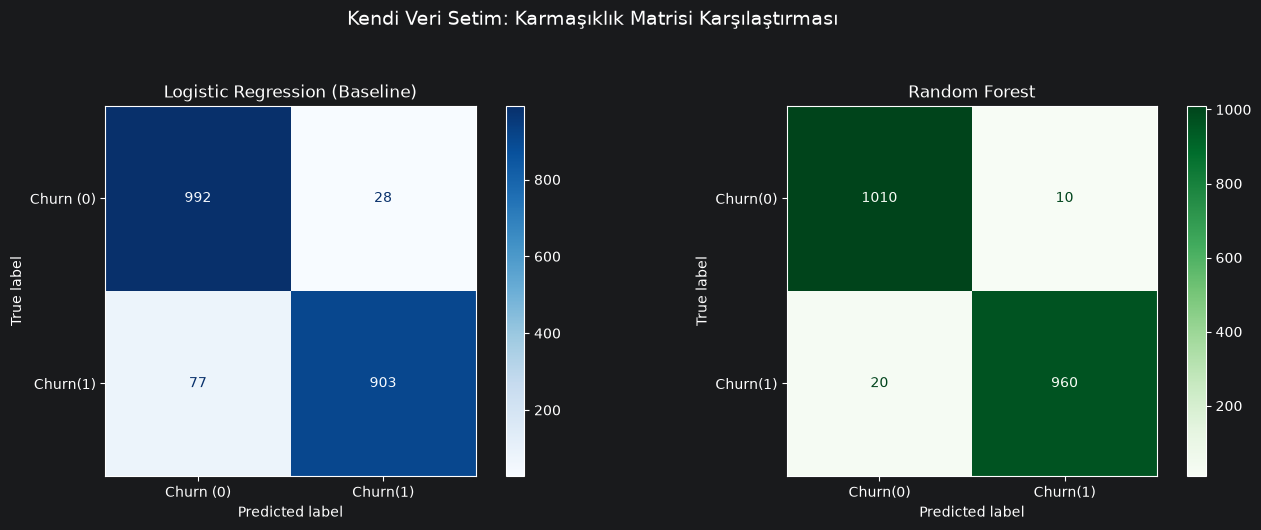

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_base_my = confusion_matrix(Y_test_my, Y_pred_base_my)
disp_base_my = ConfusionMatrixDisplay(confusion_matrix=cm_base_my, display_labels=["Churn (0)", "Churn(1)"])
disp_base_my.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression (Baseline)')


cm_rf_my = confusion_matrix(Y_test_my, Y_pred_rf_my)
disp_rf_my = ConfusionMatrixDisplay(confusion_matrix=cm_rf_my, display_labels=["Churn(0)", "Churn(1)"])
disp_rf_my.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Random Forest')

plt.suptitle('Kendi Veri Setim: Karmaşıklık Matrisi Karşılaştırması', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

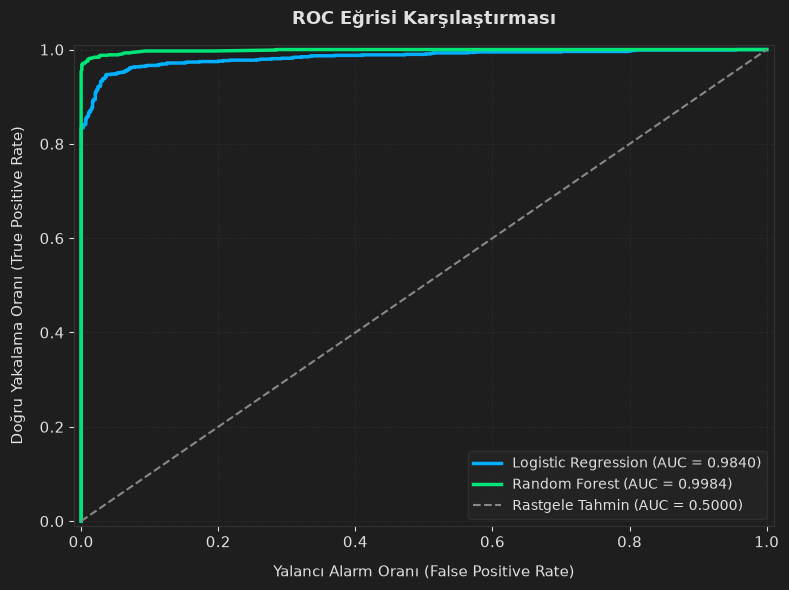

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


Y_probs_base_my = baseline_my.predict_proba(X_test_my)[:, 1]
Y_probs_rf_my = rf_my.predict_proba(X_test_my)[:, 1]


fpr_base_my, tpr_base_my, _ = roc_curve(Y_test_my, Y_probs_base_my)
roc_auc_base_my = auc(fpr_base_my, tpr_base_my)

fpr_rf_my, tpr_rf_my, _ = roc_curve(Y_test_my, Y_probs_rf_my)
roc_auc_rf_my = auc(fpr_rf_my, tpr_rf_my)


dark_bg = '#1e1e1e'
text_color = '#e0e0e0'

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)


ax.plot(fpr_base_my, tpr_base_my, color='#00b0ff', linewidth=2.5,
        label=f'Logistic Regression (AUC = {roc_auc_base_my:.4f})')
ax.plot(fpr_rf_my, tpr_rf_my, color='#00e676', linewidth=2.5,
        label=f'Random Forest (AUC = {roc_auc_rf_my:.4f})')


ax.plot([0, 1], [0, 1], color='#888888', linestyle='--', linewidth=1.5, label='Rastgele Tahmin (AUC = 0.5000)')


ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.xaxis.grid(True, color='#333333', linestyle='--', linewidth=0.7)
ax.yaxis.grid(True, color='#333333', linestyle='--', linewidth=0.7)

for spine in ax.spines.values():
    spine.set_color('#333333')

ax.tick_params(colors=text_color, which='both', labelsize=11)
ax.set_xlabel('Yalancı Alarm Oranı (False Positive Rate)', color=text_color, fontsize=11, labelpad=10)
ax.set_ylabel('Doğru Yakalama Oranı (True Positive Rate)', color=text_color, fontsize=11, labelpad=10)
ax.set_title('ROC Eğrisi Karşılaştırması', color=text_color, fontsize=13, fontweight='bold', pad=15)


legend = ax.legend(loc='lower right', facecolor='#252525', edgecolor='#333333', fontsize=10)
plt.setp(legend.get_texts(), color=text_color)

plt.tight_layout()
plt.show()